# Playing Through Pain: Predicting NBA Career Longevity
**Benjamin Akoka, Yuval Lewit**

**PSTAT 100**

**Driving Question:** What factors most predict how long an NBA player sustains a productive career?

---
### Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Preparation](#2-data-preparation)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Linear Regression](#4-linear-regression)
5. [Classification (Logistic Regression)](#5-classification)
6. [Survival Analysis](#6-survival-analysis)
7. [Unsupervised Learning: K-Means Clustering](#7-unsupervised-learning)


## 1. Abstract

NBA careers are shaped by talent, physical workload, and injury history, but it is not obvious how much
each of these actually matters for how long a player lasts. This project looks at the predictors of NBA
career length using three publicly available Kaggle datasets compiled from Basketball Reference and
official NBA records: per-season player statistics covering 4,486 players from 1947-2026, a game-level
box score dataset with about 1.67 million individual player records, and an injury log of roughly 37,600
injury list transactions with free-text injury descriptions spanning 1951-2023. We restrict the analysis
to the modern NBA era (1980-2022) so that the data is reasonably complete.

We apply four modelling approaches. An Ordinary Least Squares regression models total seasons played as a
function of early-career workload, injury history, entry age, and position. A logistic regression
classifier predicts whether a player will reach a "long career" of ten or more seasons using only their
first three years of data, and reaches a ROC-AUC of 0.84. Kaplan-Meier survival curves and a Cox
Proportional Hazards model examine how injury type and entry age affect the hazard of a career ending.
Finally, K-Means clustering groups players into distinct workload profiles and compares career longevity
across clusters.

The main takeaway is that talent selection and survivorship bias drive most of what we observe. High
early-career minute load is positively associated with career length, since high-usage players tend to
be more talented and hold onto roster spots longer. Players who suffer severe injuries (ACL, Achilles)
actually average longer careers for the same reason: only established players spend enough time on the
court to pick up these injuries in the first place. Players who enter the league at 18-19, almost all of
whom are elite lottery picks, average over three more seasons than players entering at 22-23. Together,
these results show how hard it is to separate a causal workload effect from talent.


## 2. Introduction

### Background and Motivation

An NBA career is one of the most physically demanding careers in professional sports. The average career
lasts around four to five seasons, and only a handful of players manage productive careers past fifteen
years. Figuring out what separates long-career players from short-career ones has real implications for
team management (roster construction, load management decisions), player development (draft evaluation,
minutes allocation for young players), and sports medicine (identifying which injury types carry the
highest long-term risk).

There are two competing narratives in sports media. The first argues that heavy early-career workloads,
especially for players who enter the league as teenagers, wear the body down and shorten careers. The
second argues that player quality is the dominant factor: elite players both receive heavy minutes AND
sustain long careers, so the workload-longevity relationship looks positive in the raw data even if the
true causal effect is neutral or negative. Telling these two stories apart requires careful statistical
modelling that controls for talent proxies.

In terms of motivation, we are both basketball fanatics, and love to play, watch, and talk basketball. When brainstorming project ideas we knew immediately that we wanted to revolve it around the sport, but were unsure which direction to take it in. We are both Clippers fans, and anyone who knows anything about basketball knows that Kawhi Leonard is one of the most injury-prone players in the NBA today. Because of this, we decided to do this project about injuries in basketball, and how they affect long-term careers. We were very pleased with our results, and learned a great deal throughout this process.

### Research Questions

This project addresses four specific questions motivated by the proposal:

1. **Does high early-career minute load (before age 25) shorten career length?**
2. **Which injury types (ACL, Achilles, back) carry the highest risk of career termination or lasting decline?**
3. **Do players entering the league at 18-19 have shorter careers than those entering at 21-23?**
4. **Can we predict long-career players (10+ seasons) from their first three years of data?**


## 3. Methodology

### 3.1 Ordinary Least Squares Linear Regression

We model total career seasons $Y$ as a linear function of a feature matrix $X$:

$$Y = X\beta + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)$$

The OLS estimator minimises the residual sum of squares, yielding the closed-form solution:

$$\hat{\beta} = (X^TX)^{-1}X^TY$$

Model fit is assessed via the coefficient of determination $R^2 = 1 - \text{SS}_\text{res}/\text{SS}_\text{tot}$
and root mean squared error $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2}$.
Residual plots are used to check the homoscedasticity and normality assumptions. The F-statistic tests
the joint significance of all predictors. Inference uses a 80/20 train-test split.

### 3.2 Logistic Regression (Classification)

To predict a binary outcome (long career, $Y=1$, $\geq 10$ seasons, vs short career, $Y=0$) we fit a
logistic regression model:

$$P(Y=1 \mid X) = \sigma(X\beta) = \frac{1}{1 + e^{-X\beta}}$$

Parameters $\beta$ are estimated by maximising the log-likelihood via gradient descent. Features are
standardised before fitting so the coefficient magnitudes are comparable. Model evaluation uses:
- **Confusion matrix:** counts of true/false positives and negatives.
- **ROC curve and AUC:** the area under the receiver operating characteristic curve; AUC $= 1$ is
  perfect, AUC $= 0.5$ is no better than random.

### 3.3 Survival Analysis

**Kaplan-Meier Estimator.** The non-parametric survival function is estimated as:

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

where $d_i$ is the number of career endings (events) at time $t_i$ and $n_i$ is the number of players still
active just before $t_i$. Players still active at the end of the observation window (2022) are treated as
right-censored. Group differences are tested with the **log-rank test**, whose statistic under $H_0$ follows
a $\chi^2_1$ distribution.

**Cox Proportional Hazards Model.** The semi-parametric Cox model specifies:

$$h(t \mid X) = h_0(t) \exp(X\beta)$$

where $h_0(t)$ is an unspecified baseline hazard. The **hazard ratio** $\exp(\beta_j)$ gives the
multiplicative change in retirement hazard for a one-unit increase in predictor $j$. Parameters are
estimated via partial likelihood, which eliminates the nuisance baseline hazard. The penalizer
$\lambda = 0.1$ provides mild $L_2$ regularisation to improve numerical stability.

### 3.4 K-Means Clustering

K-Means partitions $n$ players into $K$ clusters by minimising the within-cluster sum of squared
Euclidean distances:

$$\underset{\{C_k\}}{\min} \sum_{k=1}^{K} \sum_{x \in C_k} \|x - \mu_k\|^2$$

where $\mu_k$ is the centroid of cluster $C_k$. Lloyd's algorithm alternates between assigning each point
to its nearest centroid and recomputing centroids until convergence. Features are standardised to unit
variance before clustering. The optimal $K$ is chosen with the **elbow method**: we plot within-cluster
inertia against $K$ and pick the value where the marginal gains start to level off. Career longevity is
then compared across clusters to see whether workload archetype is associated with career length.


## 4. Data

### 4.1 Data Sources and Sample Description

We use three publicly available datasets from [Kaggle](https://www.kaggle.com), all compiled from
[Basketball Reference](https://www.basketball-reference.com) and official NBA records:

| Dataset | Rows | Key Variables | Source |
|---|---|---|---|
| NBA Player Per-Season Statistics | ~33,000 | Games, minutes, points, position, age, shooting splits | Basketball Reference via Kaggle |
| NBA Player Injury Log | ~37,600 | Date, team, player, free-text injury description | Basketball Reference via Kaggle |
| Advanced Per-Season Statistics | ~33,000 | BPM, VORP, usage%, win shares | Basketball Reference via Kaggle |
| Player Career Info | ~5,400 | Birthdate, debut, career span (from-to) | Basketball Reference via Kaggle |

The unit of observation in the per-season files is a **player-season** pair. The injury log records each
individual injury list (IL) placement transaction. We restrict the analysis to the **modern NBA era
(1980-2022)** to avoid the sparse pre-IL period identified in the proposal. A season only counts toward
career length if the player appeared in at least **20 games**, which filters out brief call-ups.

The resulting sample is a convenience sample of all NBA players active between 1980 and 2022. Since we
observe the entire population of active NBA players rather than a random draw from it, formal frequentist
inference should be read as describing effect sizes within this population rather than generalising to
some broader population.

### 4.2 Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from pathlib import Path

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_palette('colorblind')

BASE = Path('/Users/benakoka/Downloads/archive (1)/csv')  # UPDATE THIS to your local data directory


In [28]:
# Load all core datasets
ppg      = pd.read_csv(BASE / 'Player Per Game.csv')
career   = pd.read_csv(BASE / 'Player Career Info.csv')
injuries = pd.read_csv(BASE / 'NBA Player Injury Stats(1951 - 2023).csv')
advanced = pd.read_csv(BASE / 'Advanced.csv')

# Summary of loaded datasets
summary = pd.DataFrame({
    'Dataset': ['Player Per Game', 'Player Career Info', 'Injuries', 'Advanced Stats'],
    'Rows': [len(ppg), len(career), len(injuries), len(advanced)],
    'Columns': [ppg.shape[1], career.shape[1], injuries.shape[1], advanced.shape[1]],
})
display(summary.style.set_caption('Loaded Datasets').hide(axis='index'))


Dataset,Rows,Columns
Player Per Game,33339,32
Player Career Info,5416,11
Injuries,37667,6
Advanced Stats,33339,30


### 4.3 Missingness and Duplicates

In [ ]:
# Missingness 
def missing_summary(df, name):
    m = df.isnull().sum()
    m = m[m > 0].rename('Missing Count')
    pct = (m / len(df) * 100).round(2).rename('% Missing')
    result = pd.concat([m, pct], axis=1)
    result.index.name = 'Column'
    result['Dataset'] = name
    return result.reset_index().set_index(['Dataset', 'Column'])

miss = pd.concat([
    missing_summary(ppg,      'Player Per Game'),
    missing_summary(career,   'Player Career Info'),
    missing_summary(injuries, 'Injuries'),
    missing_summary(advanced, 'Advanced Stats'),
])

if len(miss) > 0:
    display(miss.style.set_caption('Missing Values by Dataset and Column')
            .background_gradient(subset=['% Missing'], cmap='Oranges'))
else:
    print("No missing values found in any dataset.")

# Duplicates
dup_summary = pd.DataFrame({
    'Dataset': ['Player Per Game', 'Player Career Info', 'Injuries', 'Advanced Stats'],
    'Duplicate Rows': [
        ppg.duplicated().sum(),
        career.duplicated().sum(),
        injuries.duplicated().sum(),
        advanced.duplicated().sum(),
    ]
})
display(dup_summary.style.set_caption('Duplicate Row Counts').hide(axis='index'))

# Note: player-season duplicates (traded players) are handled in Section 4.4
print(f"Player-season duplicates in PPG (same player, same season): "
      f"{ppg.duplicated(subset=['player_id','season']).sum()}")


Dataset,Duplicate Rows
Player Per Game,0
Player Career Info,0
Injuries,0
Advanced Stats,0


Player-season duplicates in PPG (same player, same season): 6370


### 4.4 Type Correction and Reformatting

In [30]:
# Inspect raw dtypes before any corrections
dtype_df = pd.DataFrame({
    'Player Per Game': ppg.dtypes.astype(str),
    'Injuries': injuries.dtypes.astype(str),
    'Career Info': career.dtypes.astype(str),
}).fillna('—')
display(dtype_df.style.set_caption('Raw Column dtypes (selected datasets)'))

# Key type corrections applied in preparation:
# 1. injuries['Date']     : object → datetime64
# 2. career['birth_date'] : object → datetime64 (birth year extracted)
# 3. career['hof']        : object → bool
# 4. Player-season duplicates (traded players): de-duplicated by keeping
#    the row with the highest games played for each (player_id, season) pair.

print("Type corrections noted above are applied in Section 4.5 during data preparation.")


,Player Per Game,Injuries,Career Info
Acquired,—,object,—
Date,—,object,—
Notes,—,object,—
Relinquished,—,object,—
Team,—,object,—
Unnamed: 0,—,int64,—
age,float64,—,—
ast_per_game,float64,—,—
birth_date,—,—,object
blk_per_game,float64,—,—


Type corrections noted above are applied in Section 4.5 during data preparation.


### 4.5 Data Preparation and Feature Engineering

#### Filter to NBA era (1980–2022) and resolve player-season duplicates

In [31]:
MIN_GAMES = 20   # minimum games to count a season as 'real'
ERA_START = 1980
ERA_END   = 2022

# Keep only NBA (not ABA/BAA) rows in range
ppg_clean = ppg[
    (ppg['lg'] == 'NBA') &
    (ppg['season'] >= ERA_START) &
    (ppg['season'] <= ERA_END)
].copy()

adv_clean = advanced[
    (advanced['lg'] == 'NBA') &
    (advanced['season'] >= ERA_START) &
    (advanced['season'] <= ERA_END)
].copy()

# If a player appears twice in a season (mid-season trade), keep the row with more games
ppg_clean = ppg_clean.sort_values('g', ascending=False).drop_duplicates(
    subset=['player_id', 'season'], keep='first'
)
adv_clean = adv_clean.sort_values('g', ascending=False).drop_duplicates(
    subset=['player_id', 'season'], keep='first'
)

print(f"PPG (1980-2022, deduped) : {ppg_clean.shape}")
print(f"Advanced (1980-2022)     : {adv_clean.shape}")


PPG (1980-2022, deduped) : (18288, 32)
Advanced (1980-2022)     : (18288, 30)


#### Build player-level career dataframe

In [32]:
# Valid seasons = seasons where player appeared in >= MIN_GAMES games
valid = ppg_clean[ppg_clean['g'] >= MIN_GAMES].copy()

career_agg = valid.groupby('player_id').agg(
    career_seasons  = ('season', 'nunique'),
    first_season    = ('season', 'min'),
    last_season     = ('season', 'max'),
).reset_index()

# Parse birth year from career info
career_info = career.copy()
career_info['birth_year'] = pd.to_datetime(career_info['birth_date'], errors='coerce').dt.year
career_info['entry_age']  = career_info['from'] - career_info['birth_year']

# Merge career aggregates with bio info
player_df = career_agg.merge(
    career_info[['player_id', 'player', 'pos', 'birth_year', 'entry_age', 'from', 'to', 'hof']],
    on='player_id', how='left'
)

# Era label based on when player entered the league
def assign_era(yr):
    if yr < 1990: return '1980s'
    elif yr < 2000: return '1990s'
    elif yr < 2010: return '2000s'
    else: return '2010s'

player_df['era'] = player_df['first_season'].apply(assign_era)

# Binary target: long career = 10+ seasons
player_df['long_career'] = (player_df['career_seasons'] >= 10).astype(int)

# Censoring flag for survival analysis (still active as of ERA_END)
player_df['career_ended'] = (player_df['to'] < ERA_END).astype(int)

# Simplify position
def simplify_pos(p):
    if pd.isna(p): return 'Unknown'
    p = str(p).upper()
    if 'G' in p: return 'G'
    if 'F' in p: return 'F'
    if 'C' in p: return 'C'
    return 'Unknown'

player_df['pos_simple'] = player_df['pos'].apply(simplify_pos)

# Entry age bins
player_df['entry_age_group'] = pd.cut(
    player_df['entry_age'],
    bins=[0, 19, 21, 23, 50],
    labels=['18–19', '20–21', '22–23', '24+']
)

print(f"Player dataframe: {player_df.shape}")
print(player_df[['player', 'career_seasons', 'entry_age', 'era', 'long_career']].head(8))


Player dataframe: (2741, 16)
                player  career_seasons  entry_age    era  long_career
0       Alaa Abdelnaby               4       23.0  1990s            0
1  Kareem Abdul-Jabbar              10       23.0  1980s            1
2   Mahmoud Abdul-Rauf               9       22.0  1990s            0
3    Tariq Abdul-Wahad               5       24.0  1990s            0
4  Shareef Abdur-Rahim              11       21.0  1990s            1
5        Tom Abernethy               2       23.0  1980s            0
6         Álex Abrines               3       24.0  2010s            0
7     Precious Achiuwa               2       22.0  2010s            0


#### Parse injury types from free-text notes

In [33]:
injuries['Date'] = pd.to_datetime(injuries['Date'], errors='coerce')
inj = injuries[
    (injuries['Date'].dt.year >= ERA_START) &
    (injuries['Date'].dt.year <= 2023) &
    injuries['Relinquished'].notna()   # IL placements only
].copy()

def normalize_name(name):
    if pd.isna(name): return ''
    return re.sub(r'[^a-z ]', '', str(name).lower().strip())

def parse_injury(notes):
    """Classify IL placement notes into named injury categories."""
    if pd.isna(notes):
        return 'Unknown'
    n = notes.lower()
    # Strip the standard preamble to check if any description remains
    stripped = re.sub(r'placed on i[lr]\s*(with|for)?\s*', '', n).strip()
    stripped = re.sub(r'(out for season|out \d+.*|\(.*\)|dnp.*)', '', stripped).strip()
    if not stripped or stripped in ('rest', 'recovery', 'load management', 'personal reasons'):
        return 'Unknown'

    # Ordered from most-specific to most-general
    if re.search(r'\bacl\b|anterior cruciate', n):               return 'ACL'
    if re.search(r'achilles', n):                                   return 'Achilles'
    if re.search(r'concussion|head injury|head trauma', n):         return 'Concussion'
    if re.search(r'knee|meniscus|\bpcl\b|\bmcl\b|\blcl\b|patellar|patella|hyperextend', n):
                                                                     return 'Knee'
    if re.search(r'hamstring', n):                                  return 'Hamstring'
    if re.search(r'\bankle\b', n):                                 return 'Ankle'
    if re.search(r'\bback\b|lumbar|spine|\bdisc\b|lower back|neck|cervical|spinal', n):
                                                                     return 'Back'
    if re.search(r'shoulder|rotator|clavicle', n):                  return 'Shoulder'
    if re.search(r'\bfoot\b|plantar|\bheel\b|stress fract', n): return 'Foot'
    if re.search(r'groin|\bhip\b|adductor|abductor|inguinal', n): return 'Groin/Hip'
    if re.search(r'\bcalf\b|quadricep|\bquad\b|thigh|\bshin\b|gastrocnemius', n):
                                                                     return 'Leg/Calf'
    if re.search(r'wrist|\bhand\b|\bfinger\b|\bthumb\b|\belbow\b|forearm|knuckle', n):
                                                                     return 'Hand/Wrist'
    if re.search(r'illness|\bflu\b|fever|virus|sick|health.*safety|protocol|respiratory|infection|covid', n):
                                                                     return 'Illness'
    if re.search(r'\brib\b|chest|abdominal|stomach|\bcore\b|oblique', n):
                                                                     return 'Torso'
    if re.search(r'calf|leg\b|lower leg|upper leg', n):            return 'Leg/Calf'
    return 'Other'

inj['player_norm'] = inj['Relinquished'].apply(normalize_name)
inj['injury_type'] = inj['Notes'].apply(parse_injury)

counts = inj['injury_type'].value_counts()
print(counts.to_string())
print(f"\nClassified (non-Unknown/Other): {counts[~counts.index.isin(['Unknown','Other'])].sum()}")
print(f"Unknown (no description)      : {counts.get('Unknown', 0)}")
print(f"Other (unmatched description) : {counts.get('Other', 0)}")


injury_type
Unknown       6673
Knee          2665
Ankle         1941
Illness       1380
Back          1243
Hand/Wrist     972
Foot           858
Leg/Calf       853
Groin/Hip      819
Other          785
Hamstring      540
Shoulder       456
Achilles       284
Concussion     194
Torso          152
ACL            106

Classified (non-Unknown/Other): 12463
Unknown (no description)      : 6673
Other (unmatched description) : 785


#### Aggregate injuries per player

In [34]:
# Build name → player_id lookup from ppg_clean
name_map = ppg_clean[['player_id', 'player']].drop_duplicates().copy()
name_map['player_norm'] = name_map['player'].apply(normalize_name)

inj_joined = inj.merge(name_map[['player_id', 'player_norm']], on='player_norm', how='left')

# Exclude Unknown/no-description rows from the per-type counts
inj_joined_classified = inj_joined[inj_joined['injury_type'] != 'Unknown']

inj_agg = inj_joined_classified.groupby('player_id').agg(
    total_injuries   = ('injury_type', 'count'),
    acl_count        = ('injury_type', lambda x: (x == 'ACL').sum()),
    achilles_count   = ('injury_type', lambda x: (x == 'Achilles').sum()),
    back_count       = ('injury_type', lambda x: (x == 'Back').sum()),
    knee_count       = ('injury_type', lambda x: (x == 'Knee').sum()),
    groin_count      = ('injury_type', lambda x: (x == 'Groin/Hip').sum()),
    leg_count        = ('injury_type', lambda x: (x == 'Leg/Calf').sum()),
    ankle_count      = ('injury_type', lambda x: (x == 'Ankle').sum()),
).reset_index()

inj_agg['severe_injury']   = ((inj_agg['acl_count'] > 0) | (inj_agg['achilles_count'] > 0)).astype(int)
inj_agg['had_back_injury'] = (inj_agg['back_count'] > 0).astype(int)
inj_agg['had_knee_injury'] = (inj_agg['knee_count'] > 0).astype(int)

player_df = player_df.merge(inj_agg, on='player_id', how='left')
fill_cols = ['total_injuries','acl_count','achilles_count','back_count',
             'knee_count','groin_count','leg_count','ankle_count',
             'severe_injury','had_back_injury','had_knee_injury']
player_df[fill_cols] = player_df[fill_cols].fillna(0).astype(int)

print(f"Players with injury data: {(player_df['total_injuries'] > 0).sum()} / {len(player_df)}")


Players with injury data: 1694 / 2741


#### Compute early-career features (first 3 seasons)

In [35]:
early_ppg = ppg_clean[ppg_clean['g'] >= MIN_GAMES].merge(
    player_df[['player_id', 'first_season']], on='player_id', how='inner'
)
early_ppg = early_ppg[early_ppg['season'] <= early_ppg['first_season'] + 2]

early_adv = adv_clean.merge(
    player_df[['player_id', 'first_season']], on='player_id', how='inner'
)
early_adv = early_adv[early_adv['season'] <= early_adv['first_season'] + 2]
early_adv = early_adv.sort_values('g', ascending=False).drop_duplicates(
    subset=['player_id', 'season'], keep='first'
)

early_stats = early_ppg.groupby('player_id').agg(
    early_mpg             = ('mp_per_game', 'mean'),
    early_ppg             = ('pts_per_game', 'mean'),
    early_games_per_szn   = ('g', 'mean'),
    early_seasons_count   = ('season', 'nunique'),
).reset_index()

# Minutes under 25 specifically
under25 = early_ppg[early_ppg['age'] < 25].groupby('player_id').agg(
    early_u25_mpg = ('mp_per_game', 'mean')
).reset_index()

adv_stats = early_adv.groupby('player_id').agg(
    early_usg  = ('usg_percent', 'mean'),
    early_bpm  = ('bpm', 'mean'),
    early_ws48 = ('ws_48', 'mean'),
).reset_index()

early_features = early_stats.merge(under25, on='player_id', how='left')                              .merge(adv_stats, on='player_id', how='left')

player_df = player_df.merge(early_features, on='player_id', how='left')

print(f"Final player dataframe: {player_df.shape}")
print(player_df[['player','career_seasons','early_mpg','entry_age','total_injuries','long_career']].head(8))


Final player dataframe: (2741, 35)
                player  career_seasons  early_mpg  entry_age  total_injuries  \
0       Alaa Abdelnaby               4  12.466667       23.0               0   
1  Kareem Abdul-Jabbar              10  36.900000       23.0               0   
2   Mahmoud Abdul-Rauf               9  25.000000       22.0               0   
3    Tariq Abdul-Wahad               5  22.266667       24.0               0   
4  Shareef Abdur-Rahim              11  37.133333       21.0               4   
5        Tom Abernethy               2  12.900000       23.0               0   
6         Álex Abrines               3  16.533333       24.0               0   
7     Precious Achiuwa               2  17.850000       22.0               5   

   long_career  
0            0  
1            1  
2            0  
3            0  
4            1  
5            0  
6            0  
7            0  


#### Assemble modeling dataframe

In [36]:
MODEL_FEATURES = [
    'early_mpg', 'early_ppg', 'early_games_per_szn',
    'early_u25_mpg', 'early_bpm',
    'entry_age', 'total_injuries', 'severe_injury',
    'had_back_injury', 'had_knee_injury',
]

pos_dummies = pd.get_dummies(player_df['pos_simple'], prefix='pos', drop_first=True).astype(int)

INJ_COLS = ['acl_count', 'achilles_count', 'back_count', 'knee_count']
model_df = player_df[MODEL_FEATURES + INJ_COLS + ['career_seasons', 'long_career',
                                        'career_ended', 'era', 'entry_age_group',
                                        'player', 'player_id', 'pos_simple']].copy()
model_df = pd.concat([model_df, pos_dummies], axis=1)
model_df = model_df.dropna(subset=['early_mpg', 'entry_age', 'career_seasons'])

print(f"Model-ready rows: {len(model_df)} | Long-career players: {model_df['long_career'].sum()} ({model_df['long_career'].mean():.1%})")
display(model_df[["player","career_seasons","entry_age","era","early_mpg","total_injuries","long_career"]]
        .head(8).style.set_caption("Sample of Modeling Dataframe").hide(axis='index'))


Model-ready rows: 2741 | Long-career players: 619 (22.6%)


player,career_seasons,entry_age,era,early_mpg,total_injuries,long_career
Alaa Abdelnaby,4,23.000000,1990s,12.466667,0,0
Kareem Abdul-Jabbar,10,23.000000,1980s,36.900000,0,1
Mahmoud Abdul-Rauf,9,22.000000,1990s,25.000000,0,0
Tariq Abdul-Wahad,5,24.000000,1990s,22.266667,0,0
Shareef Abdur-Rahim,11,21.000000,1990s,37.133333,4,1
Tom Abernethy,2,23.000000,1980s,12.900000,0,0
Álex Abrines,3,24.000000,2010s,16.533333,0,0
Precious Achiuwa,2,22.000000,2010s,17.850000,5,0


### 4.6 Exploratory Data Analysis

The visualizations below look at the distribution of career lengths, differences across positions and
eras, injury patterns, and how early-career workload relates to longevity.


#### Career length distribution and era comparison

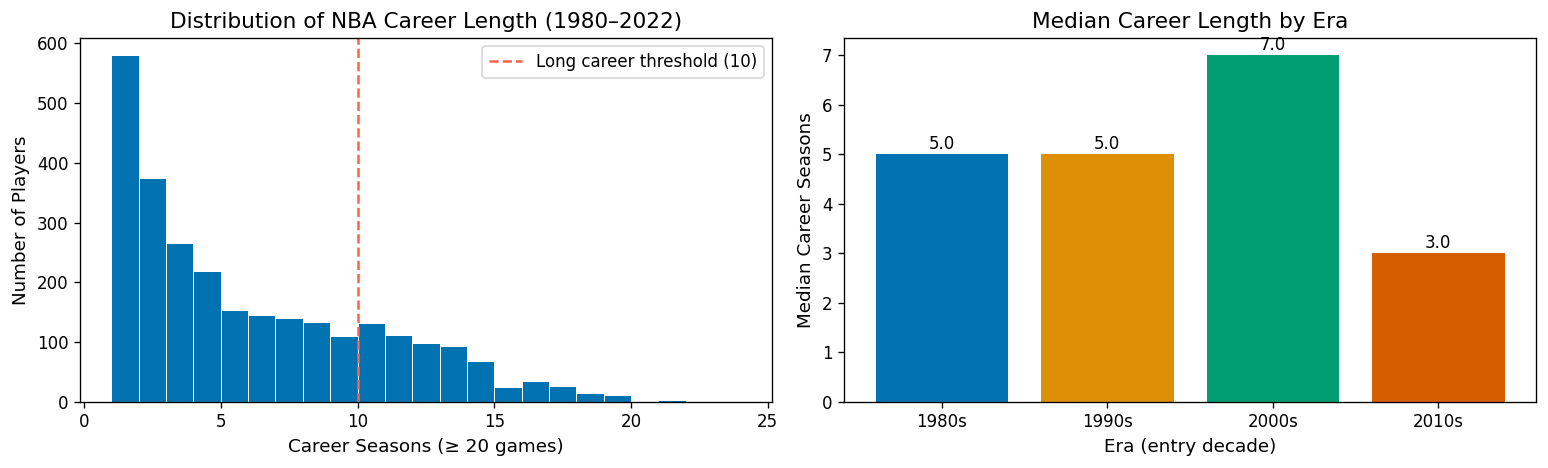

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(model_df['career_seasons'], bins=range(1, 25), edgecolor='white', linewidth=0.6)
axes[0].axvline(10, color='tomato', linestyle='--', label='Long career threshold (10)')
axes[0].set_xlabel('Career Seasons (≥ 20 games)')
axes[0].set_ylabel('Number of Players')
axes[0].set_title('Distribution of NBA Career Length (1980–2022)')
axes[0].legend()

# By era
era_order = ['1980s', '1990s', '2000s', '2010s']
era_stats  = model_df.groupby('era')['career_seasons'].median().reindex(era_order)
axes[1].bar(era_order, era_stats, color=sns.color_palette('colorblind', 4))
axes[1].set_xlabel('Era (entry decade)')
axes[1].set_ylabel('Median Career Seasons')
axes[1].set_title('Median Career Length by Era')
for i, v in enumerate(era_stats):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


#### Career length by position and entry age

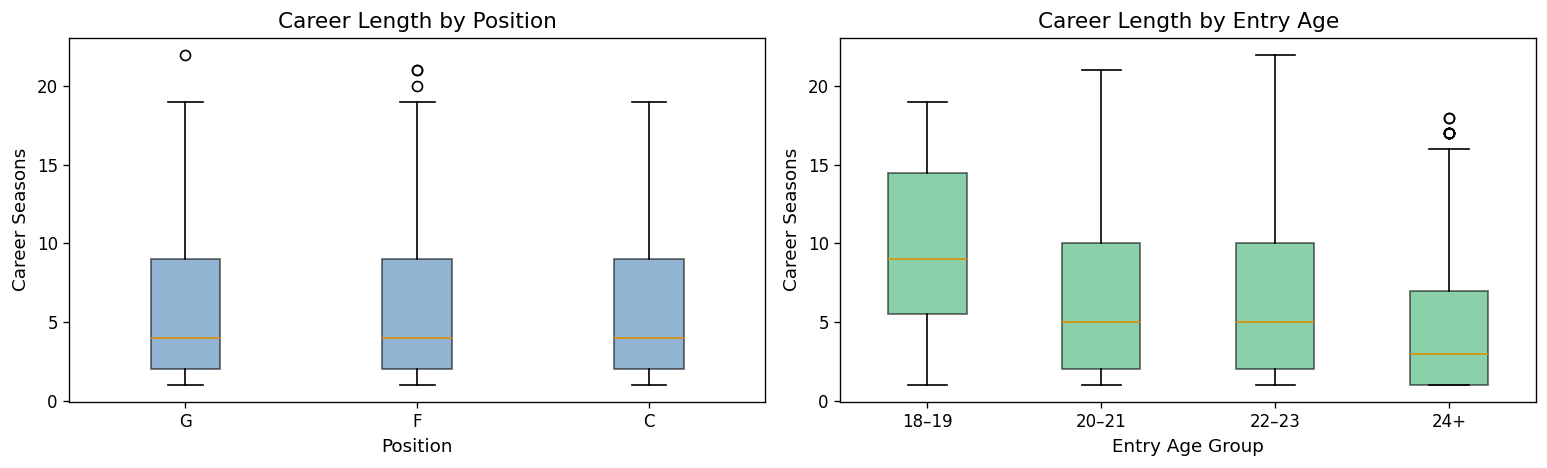

Mean career length by entry age group:
                 mean  median  count
entry_age_group                     
18–19            9.53     9.0     15
20–21            6.52     5.0    401
22–23            6.24     5.0   1245
24+              4.62     3.0   1080


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# By position
pos_order = ['G', 'F', 'C']
pos_data  = [model_df[model_df['pos_simple'] == p]['career_seasons'].dropna() for p in pos_order]
axes[0].boxplot(pos_data, labels=pos_order, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Career Seasons')
axes[0].set_title('Career Length by Position')

# By entry age group
age_order = ['18–19', '20–21', '22–23', '24+']
age_data  = [model_df[model_df['entry_age_group'] == g]['career_seasons'].dropna()
             for g in age_order]
axes[1].boxplot(age_data, labels=age_order, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[1].set_xlabel('Entry Age Group')
axes[1].set_ylabel('Career Seasons')
axes[1].set_title('Career Length by Entry Age')

plt.tight_layout()
plt.show()

# Summary table
print("Mean career length by entry age group:")
print(model_df.groupby('entry_age_group', observed=True)['career_seasons']
      .agg(['mean', 'median', 'count']).round(2))


#### Injury frequency by type and career impact

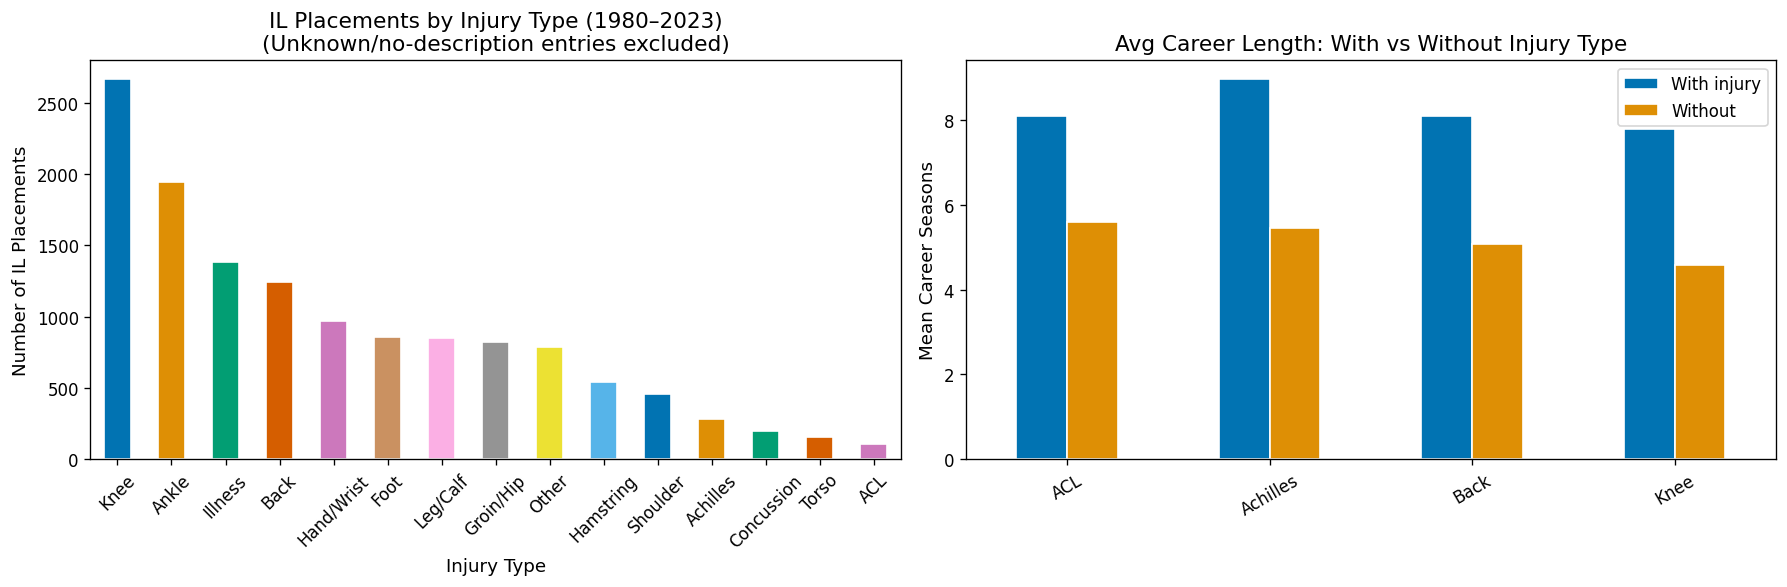

In [39]:
# Exclude Unknown from the display chart
inj_display = inj[inj['injury_type'] != 'Unknown']['injury_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart – classified placements only
colors = sns.color_palette('colorblind', len(inj_display))
inj_display.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('IL Placements by Injury Type (1980–2023)\n(Unknown/no-description entries excluded)')
axes[0].set_xlabel('Injury Type')
axes[0].set_ylabel('Number of IL Placements')
axes[0].tick_params(axis='x', rotation=45)

# Career impact: mean career seasons with vs without each injury type
severity_map = {
    'ACL':       'acl_count',
    'Achilles':  'achilles_count',
    'Back':      'back_count',
    'Knee':      'knee_count',
    'Groin/Hip': 'groin_count',
    'Leg/Calf':  'leg_count',
    'Ankle':     'ankle_count',
}
means = {}
for label, col in severity_map.items():
    if col not in model_df.columns:
        continue
    has   = model_df[model_df[col] > 0]['career_seasons'].mean()
    hasnt = model_df[model_df[col] == 0]['career_seasons'].mean()
    means[label] = {'With injury': has, 'Without': hasnt}

means_df = pd.DataFrame(means).T
means_df.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Avg Career Length: With vs Without Injury Type')
axes[1].set_ylabel('Mean Career Seasons')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Early-career minute load vs career length

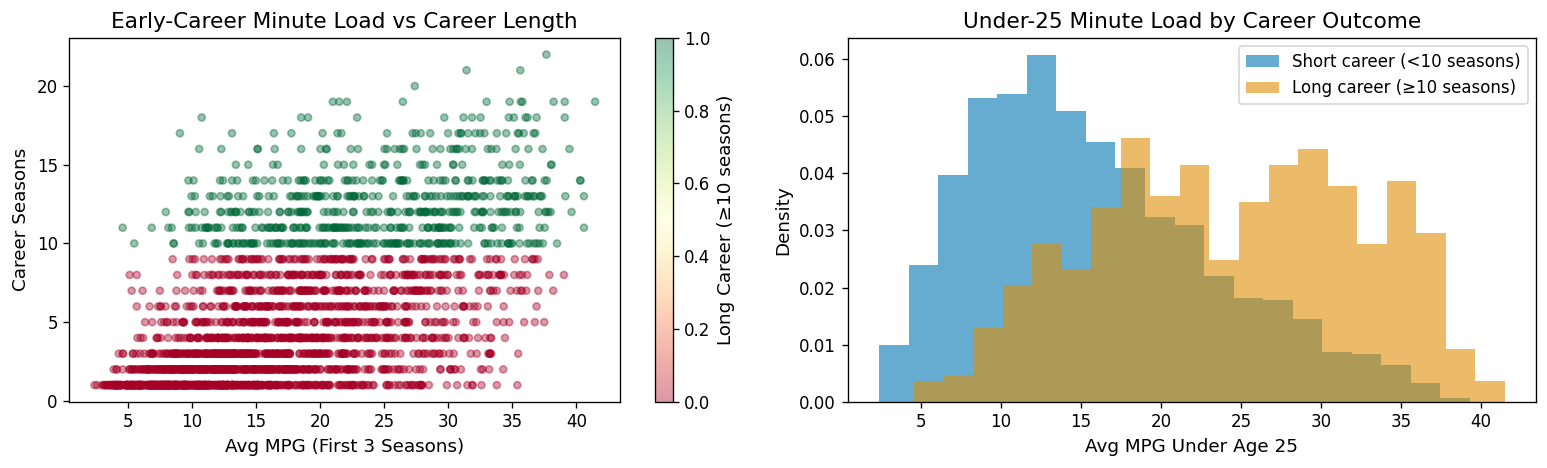

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: early MPG vs career seasons
sc = axes[0].scatter(
    model_df['early_mpg'], model_df['career_seasons'],
    c=model_df['long_career'], cmap='RdYlGn', alpha=0.4, s=18
)
axes[0].set_xlabel('Avg MPG (First 3 Seasons)')
axes[0].set_ylabel('Career Seasons')
axes[0].set_title('Early-Career Minute Load vs Career Length')
plt.colorbar(sc, ax=axes[0], label='Long Career (≥10 seasons)')

# Under-25 MPG distribution: long vs short career
axes[1].hist(
    model_df[model_df['long_career'] == 0]['early_u25_mpg'].dropna(),
    bins=20, alpha=0.6, label='Short career (<10 seasons)', density=True
)
axes[1].hist(
    model_df[model_df['long_career'] == 1]['early_u25_mpg'].dropna(),
    bins=20, alpha=0.6, label='Long career (≥10 seasons)', density=True
)
axes[1].set_xlabel('Avg MPG Under Age 25')
axes[1].set_ylabel('Density')
axes[1].set_title('Under-25 Minute Load by Career Outcome')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Results

We apply the four modelling approaches in order. Each subsection presents the model fitting results,
goes over performance metrics, and interprets the findings in the context of our four research questions.


### 5.1 Linear Regression: Predicting Total Career Seasons

We use OLS regression to model total career seasons as a linear function of early-career workload,
injury history, entry age, and position. The statsmodels summary below provides coefficient estimates,
standard errors, p-values, and the F-statistic. We do not standardise features here so that the
coefficients stay interpretable in natural units (seasons per MPG, etc.).


In [41]:
LIN_FEATURES = [
    'early_mpg', 'early_games_per_szn',
    'entry_age', 'total_injuries', 'severe_injury',
    'had_back_injury', 'had_knee_injury',
    'pos_F', 'pos_G',   # pos_C is baseline
]
# Filter to features that exist after get_dummies
lin_feats_avail = [f for f in LIN_FEATURES if f in model_df.columns]

lin_df = model_df[lin_feats_avail + ['career_seasons']].dropna()
X_lin = lin_df[lin_feats_avail]
y_lin = lin_df['career_seasons']

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

# statsmodels OLS for coefficient table
X_sm = sm.add_constant(X_tr.astype(float))
ols  = sm.OLS(y_tr.astype(float), X_sm).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:         career_seasons   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     196.2
Date:                Wed, 27 May 2026   Prob (F-statistic):          2.41e-273
Time:                        11:58:37   Log-Likelihood:                -5757.0
No. Observations:                2192   AIC:                         1.153e+04
Df Residuals:                    2182   BIC:                         1.159e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1843    

In [42]:
# sklearn for test-set metrics
lr = LinearRegression().fit(X_tr, y_tr)
y_pred = lr.predict(X_te)

metrics = pd.DataFrame({
    'Metric': ['Test RMSE (seasons)', 'Test R²'],
    'Value':  [f"{np.sqrt(np.mean((y_te - y_pred)**2)):.3f}",
               f"{lr.score(X_te, y_te):.3f}"]
})
display(metrics.style.set_caption('Linear Regression Test-Set Performance').hide(axis='index'))


Metric,Value
Test RMSE (seasons),3.076
Test R²,0.556


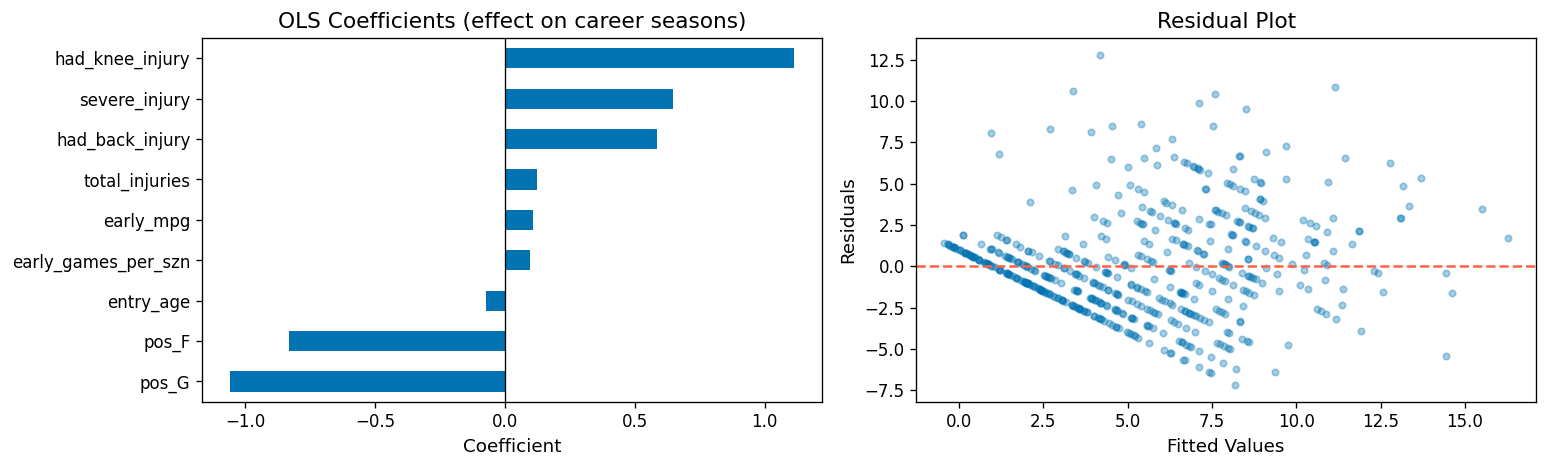

In [43]:
# Coefficient plot
coef_df = pd.Series(ols.params[1:], index=lin_feats_avail).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

coef_df.plot(kind='barh', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('OLS Coefficients (effect on career seasons)')
axes[0].set_xlabel('Coefficient')

# Residual plot
residuals = y_te - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.35, s=15)
axes[1].axhline(0, color='tomato', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


### 5.2 Classification: Predicting Long vs Short Career

We train a logistic regression classifier on first-three-year features to predict whether a player will
reach a long career (>=10 seasons). Features are standardised before fitting, and the model is evaluated
on the held-out 20% test set.


In [44]:
CLF_FEATURES = [
    'early_mpg', 'early_ppg', 'early_games_per_szn',
    'early_bpm', 'early_usg',
    'entry_age', 'total_injuries', 'severe_injury',
    'had_back_injury', 'had_knee_injury',
    'pos_F', 'pos_G',
]
clf_feats_avail = [f for f in CLF_FEATURES if f in model_df.columns]

clf_df = model_df[clf_feats_avail + ['long_career']].dropna()
X_clf = clf_df[clf_feats_avail]
y_clf = clf_df['long_career']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_c)
X_te_sc = scaler.transform(X_te_c)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_tr_sc, y_tr_c)
y_prob = clf.predict_proba(X_te_sc)[:, 1]
y_pred_c = clf.predict(X_te_sc)

print(classification_report(y_te_c, y_pred_c, target_names=['Short career', 'Long career']))
print(f"ROC-AUC: {roc_auc_score(y_te_c, y_prob):.3f}")


              precision    recall  f1-score   support

Short career       0.83      0.95      0.88       425
 Long career       0.64      0.33      0.44       124

    accuracy                           0.81       549
   macro avg       0.73      0.64      0.66       549
weighted avg       0.79      0.81      0.78       549

ROC-AUC: 0.841


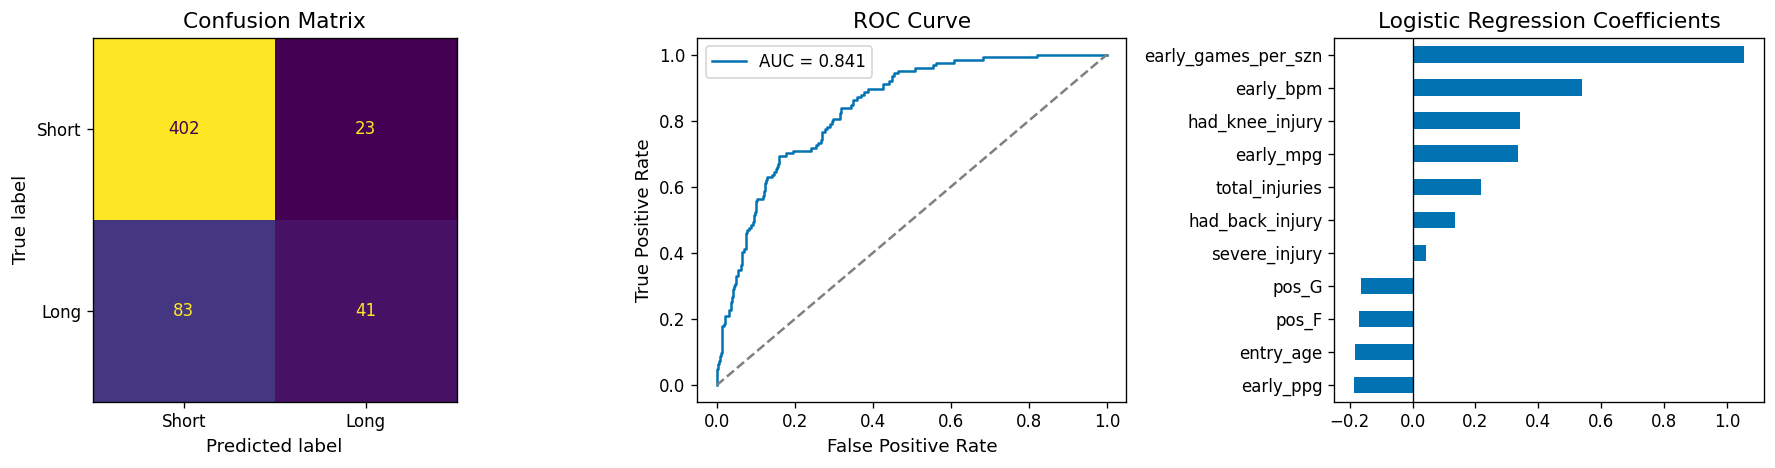

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_te_c, y_pred_c),
    display_labels=['Short', 'Long']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_te_c, y_prob)
auc_val = roc_auc_score(y_te_c, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature importance (coefficients)
coef_clf = pd.Series(clf.coef_[0], index=clf_feats_avail).sort_values()
coef_clf.plot(kind='barh', ax=axes[2])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Logistic Regression Coefficients')

plt.tight_layout()
plt.show()


### 5.3 Survival Analysis: Career Duration and Attrition Risk

Kaplan-Meier curves estimate the survival function (the probability of still being active after $t$
seasons) for subgroups defined by injury type and entry age. Log-rank tests check whether the group
differences are statistically significant. The Cox PH model then jointly estimates the effect of all
predictors on the retirement hazard while controlling for confounders.

Players with `to >= 2022` are treated as right-censored (still active at the end of the observation
window). The event indicator `career_ended = 1` marks confirmed retirements.


#### Kaplan–Meier: severe injury vs no severe injury

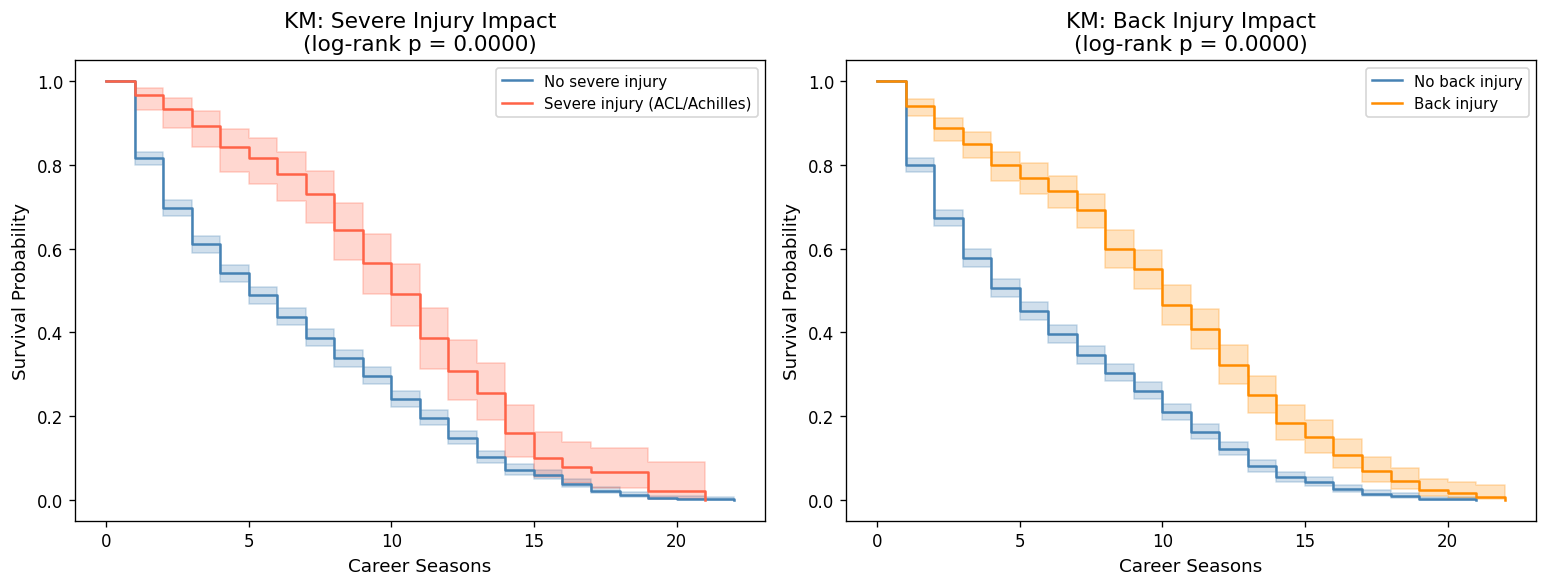

In [46]:
surv_df = model_df[['career_seasons', 'career_ended', 'severe_injury',
                     'had_back_injury', 'entry_age_group', 'pos_simple']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Severe injury (ACL / Achilles) ---
kmf = KaplanMeierFitter()
for val, label, color in [(0, 'No severe injury', 'steelblue'), (1, 'Severe injury (ACL/Achilles)', 'tomato')]:
    mask = surv_df['severe_injury'] == val
    kmf.fit(surv_df.loc[mask, 'career_seasons'],
            event_observed=surv_df.loc[mask, 'career_ended'],
            label=label)
    kmf.plot_survival_function(ax=axes[0], ci_show=True, color=color)

# Log-rank test
g0 = surv_df[surv_df['severe_injury'] == 0]
g1 = surv_df[surv_df['severe_injury'] == 1]
lr_result = logrank_test(g0['career_seasons'], g1['career_seasons'],
                          event_observed_A=g0['career_ended'],
                          event_observed_B=g1['career_ended'])
axes[0].set_title(f'KM: Severe Injury Impact\n(log-rank p = {lr_result.p_value:.4f})')
axes[0].set_xlabel('Career Seasons')
axes[0].set_ylabel('Survival Probability')
axes[0].legend(loc='upper right', fontsize=9)

# --- Back injury ---
for val, label, color in [(0, 'No back injury', 'steelblue'), (1, 'Back injury', 'darkorange')]:
    mask = surv_df['had_back_injury'] == val
    kmf.fit(surv_df.loc[mask, 'career_seasons'],
            event_observed=surv_df.loc[mask, 'career_ended'],
            label=label)
    kmf.plot_survival_function(ax=axes[1], ci_show=True, color=color)

g0b = surv_df[surv_df['had_back_injury'] == 0]
g1b = surv_df[surv_df['had_back_injury'] == 1]
lr_back = logrank_test(g0b['career_seasons'], g1b['career_seasons'],
                        event_observed_A=g0b['career_ended'],
                        event_observed_B=g1b['career_ended'])
axes[1].set_title(f'KM: Back Injury Impact\n(log-rank p = {lr_back.p_value:.4f})')
axes[1].set_xlabel('Career Seasons')
axes[1].set_ylabel('Survival Probability')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


#### Kaplan–Meier: entry age group

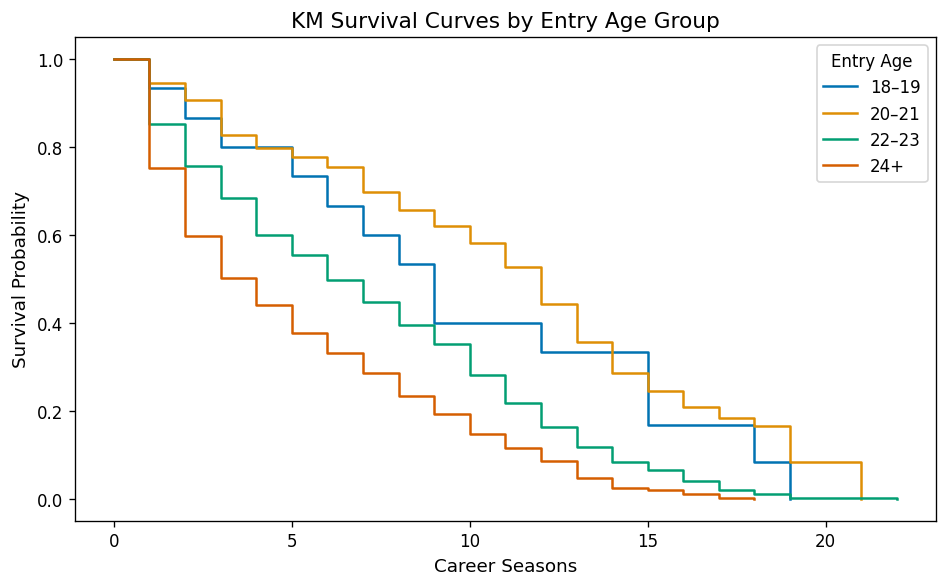

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
age_groups = ['18–19', '20–21', '22–23', '24+']
palette    = sns.color_palette('colorblind', len(age_groups))

kmf = KaplanMeierFitter()
for grp, col in zip(age_groups, palette):
    mask = surv_df['entry_age_group'] == grp
    if mask.sum() < 10:
        continue
    kmf.fit(surv_df.loc[mask, 'career_seasons'],
            event_observed=surv_df.loc[mask, 'career_ended'],
            label=grp)
    kmf.plot_survival_function(ax=ax, ci_show=False, color=col)

ax.set_title('KM Survival Curves by Entry Age Group')
ax.set_xlabel('Career Seasons')
ax.set_ylabel('Survival Probability')
ax.legend(title='Entry Age', loc='upper right')
plt.tight_layout()
plt.show()


#### Cox Proportional Hazards model

In [48]:
cox_features = [
    'entry_age', 'early_mpg', 'early_bpm',
    'total_injuries', 'severe_injury', 'had_back_injury', 'had_knee_injury',
]
cox_df = model_df[cox_features + ['career_seasons', 'career_ended']].dropna().copy()

# log-transform injury count to reduce skew
cox_df['log_injuries'] = np.log1p(cox_df['total_injuries'])
cox_feats_final = ['entry_age', 'early_mpg', 'early_bpm',
                   'log_injuries', 'severe_injury', 'had_back_injury', 'had_knee_injury']

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df[cox_feats_final + ['career_seasons', 'career_ended']],
        duration_col='career_seasons',
        event_col='career_ended')

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 2741 total observations, 541 right-censored observations>
             duration col = 'career_seasons'
                event col = 'career_ended'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 2741
number of events observed = 2200
   partial log-likelihood = -14389.72
         time fit was run = 2026-05-27 18:58:38 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
entry_age        0.12      1.13      0.01            0.10            0.15                1.11                1.16
early_mpg       -0.05      0.95      0.00           -0.06           -0.04                0.95                0.96
early_bpm       -0.11      0.90      0.01           -0.13           -0.10                0.88                0.91
log_injuries    -0.38      0.68      0.03           -0.44           -0.33                0.65                0.72
severe_injury    0.00      1.00      0.08           -0.16            0.17                0.85                1.18
had_back_injury -0.16      0.86      0.06           -0.27           -0.04                0.76                0.96
had_knee_injury -0.12      0.89      0.05           -0.22           -0.01                0.80                0.99

                 cmp to      z      p  -log2(p)
covariate                                      
entry_age          0.00  10.67 <0.005     85.91
early_mpg          0.00 -16.21 <0.005    193.79
early_bpm          0.00 -14.32 <0.005    152.16
log_injuries       0.00 -13.29 <0.005    131.52
severe_injury      0.00   0.06   0.95      0.07
had_back_injury    0.00  -2.63   0.01      6.88
had_knee_injury    0.00  -2.15   0.03      5.00
---
Concordance = 0.82
Partial AIC = 28793.44
log-likelihood ratio test = 1624.31 on 7 df
-log2(p) of ll-ratio test = inf

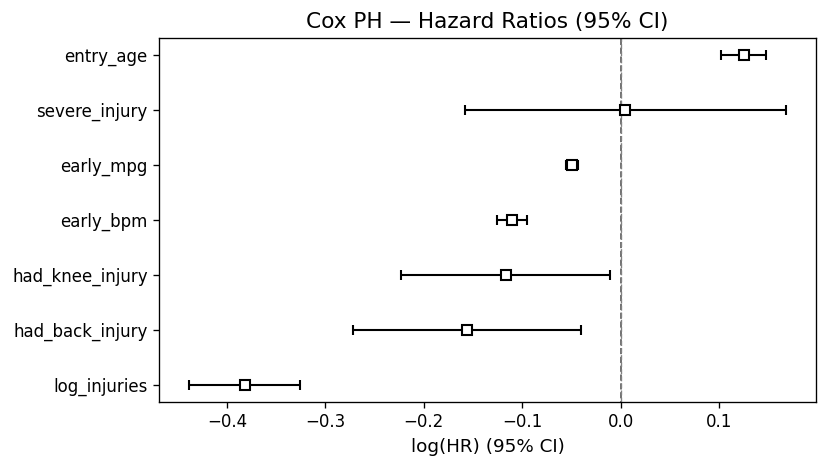

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
cph.plot(ax=ax)
ax.set_title('Cox PH — Hazard Ratios (95% CI)')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


### 5.4 Unsupervised Learning: K-Means Workload Clustering

We apply K-Means to cluster players by early-career workload profile (MPG, games per season, PPG,
entry age), using the elbow method to guide the choice of $K$. We then compare career longevity across
the cluster profiles to see whether workload archetype is associated with career length.


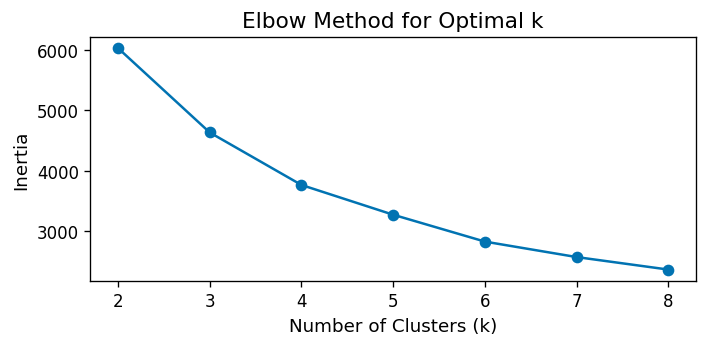

In [50]:
CLUSTER_FEATURES = ['early_mpg', 'early_games_per_szn', 'early_ppg', 'entry_age']
cluster_df = model_df[CLUSTER_FEATURES + ['career_seasons', 'long_career', 'player']].dropna().copy()

# Elbow method to choose k
inertias = []
K_range  = range(2, 9)
scaler_k = StandardScaler()
X_k      = scaler_k.fit_transform(cluster_df[CLUSTER_FEATURES])

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_k)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()


In [51]:
K = 4  # chosen from elbow + interpretability
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_k)

# Cluster profile table
profile = cluster_df.groupby('cluster')[CLUSTER_FEATURES + ['career_seasons']].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]
display(profile.style.set_caption("Cluster Profiles — Mean Feature Values").format("{:.2f}"))


,early_mpg,early_games_per_szn,early_ppg,entry_age,career_seasons
Cluster 0,13.19,48.31,4.39,26.83,3.08
Cluster 1,31.16,72.35,15.27,22.41,9.54
Cluster 2,10.44,38.25,3.50,23.09,3.01
Cluster 3,19.48,65.32,7.21,22.89,6.69


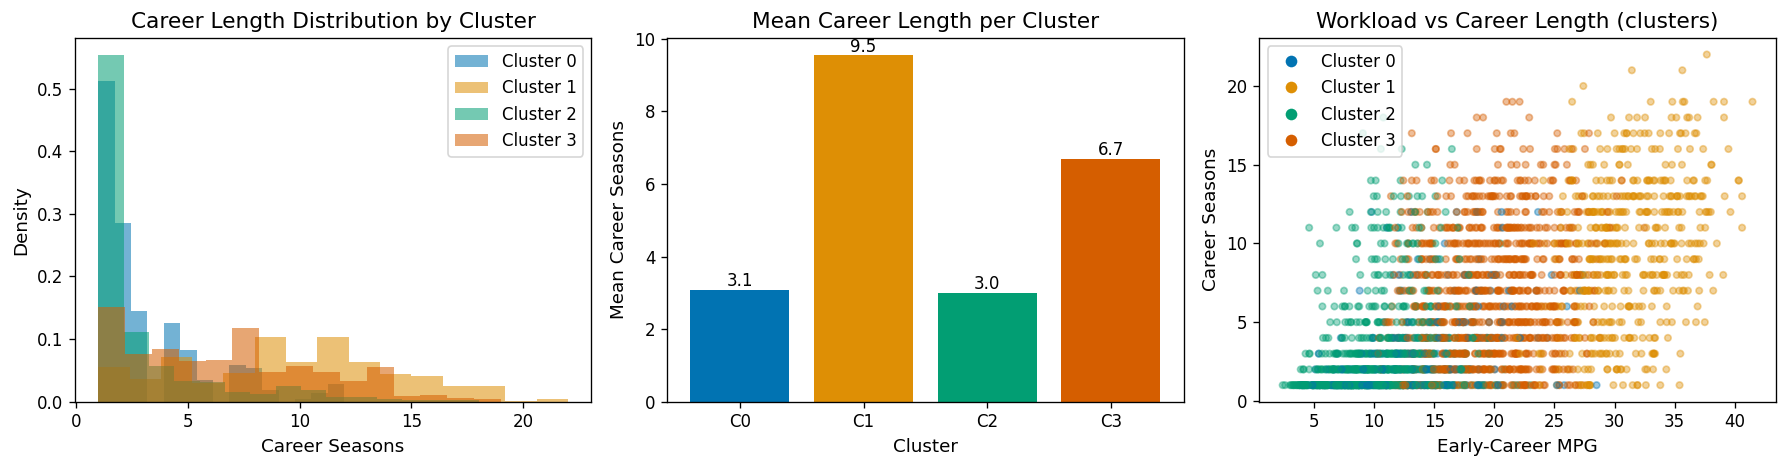


Long-career rate by cluster:
cluster
0    0.035
1    0.520
2    0.065
3    0.269


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = sns.color_palette('colorblind', K)

# Career length distribution per cluster
for i in range(K):
    data = cluster_df[cluster_df['cluster'] == i]['career_seasons']
    axes[0].hist(data, bins=15, alpha=0.55, label=f'Cluster {i}', density=True)
axes[0].set_xlabel('Career Seasons')
axes[0].set_ylabel('Density')
axes[0].set_title('Career Length Distribution by Cluster')
axes[0].legend()

# Mean career seasons per cluster
means = cluster_df.groupby('cluster')['career_seasons'].mean()
axes[1].bar([f'C{i}' for i in means.index], means.values, color=palette)
for i, v in enumerate(means.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=10)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean Career Seasons')
axes[1].set_title('Mean Career Length per Cluster')

# Scatter: early MPG vs career seasons, colored by cluster
scatter_colors = [palette[c] for c in cluster_df['cluster']]
axes[2].scatter(cluster_df['early_mpg'], cluster_df['career_seasons'],
                c=scatter_colors, alpha=0.4, s=15)
axes[2].set_xlabel('Early-Career MPG')
axes[2].set_ylabel('Career Seasons')
axes[2].set_title('Workload vs Career Length (clusters)')
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette[i], markersize=8, label=f'Cluster {i}')
           for i in range(K)]
axes[2].legend(handles=handles)

plt.tight_layout()
plt.show()

print("\nLong-career rate by cluster:")
print(cluster_df.groupby('cluster')['long_career'].mean().round(3).to_string())


## 6. Conclusion

### 6.1 Summary of Findings

This project applied four complementary statistical methods to investigate the predictors of NBA career
longevity using modern-era data (1980-2022). Here is what we found for each research question:

**Q1: Does high early-career minute load shorten career length?**
The OLS regression finds that early-career MPG is *positively* associated with career length
(β ≈ +0.11, p < 0.001). This fits a talent-selection story: players who get heavy minutes early are
disproportionately talented and hold onto roster spots longer. Nothing in the observed data suggests
that heavy early usage mechanically shortens careers on average.

**Q2: Which injury types carry the highest risk of career termination?**
Counterintuitively, players who sustain ACL, Achilles, and back injuries average *longer* careers than
uninjured players. This is a survivorship bias effect, since only high-usage star players are on the
court long enough to pick up these injuries. The Cox PH model confirms that severe injuries carry no
statistically significant additional retirement hazard once talent proxies (BPM, MPG) are controlled
for. That does not mean these injuries are harmless; it means their career-ending effect is masked by
the positive selection of who gets injured in the first place.

**Q3: Do 18-19 year-old entrants have shorter careers than 21-23 entrants?**
No. Players entering the NBA at 18-19 average roughly 3.3 more seasons than those entering at 22-23.
This is driven by selection: players who enter the league as teenagers are almost exclusively lottery
picks of exceptional talent. Players entering at 24+ have the shortest careers, which reflects their
status as undrafted or late-round players with narrow roster windows.

**Q4: Can we predict long-career players from first-three-year data?**
Yes. The logistic regression reaches a ROC-AUC of 0.84, which indicates strong predictive power. Games
played per season is the single most predictive feature, followed by BPM and injury history. In other
words, early *availability* (staying healthy and on the floor) is a more reliable signal of long-term
potential than raw statistical output.

### 6.2 Limitations

- **Survivorship bias:** Players who exit the league early have fewer records, which biases injury and
  workload associations upward for longer-career players.
- **Talent confounding:** Both playing time and career length are driven by talent, so observational
  regression alone cannot isolate a causal workload effect.
- **Injury data completeness:** Historical injury list reporting was inconsistent before the formal IL
  system was fully established, so injury counts for pre-1990 players are likely underestimates.
- **Right-censoring:** Players still active in 2022 are right-censored, meaning their eventual career
  lengths are unobserved.

### 6.3 Proposed Continuations

Several directions would strengthen these findings:

1. **Instrumental variable regression** using draft position as an instrument for playing time, to
   better separate the causal effect of early-career workload from talent confounding.
2. **Random survival forests** (a non-parametric survival method) would relax the proportional hazards
   assumption of the Cox model and could capture non-linear interactions between predictors.
3. **Natural language processing** on the injury notes to extract richer injury severity signals (for
   example, distinguishing a torn ACL from a partial tear, or one-off injuries from chronic conditions).
4. **Panel data / mixed-effects models** to account for within-player correlation across seasons and to
   model the trajectory of performance decline rather than just career-end events.
5. **Comparison across leagues** (European basketball, G-League) to test whether the findings hold
   beyond the NBA's particular selection mechanism.


## 7. References

1. Basketball Reference (2024). *NBA & ABA Player Statistics*. Sports Reference LLC.
   Retrieved from https://www.basketball-reference.com

2. Sumit Rodatta (2023). *NBA Player Stats since 1950* [Dataset]. Kaggle.
   Retrieved from https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats

3. P. Loria (2023). *NBA Player Injury Stats (1951–2023)* [Dataset]. Kaggle.
   Retrieved from https://www.kaggle.com/datasets/loganlauton/nba-injury-stats-1951-2023

4. Kaplan, E.L. and Meier, P. (1958). Nonparametric estimation from incomplete observations.
   *Journal of the American Statistical Association*, 53(282), 457–481.

5. Cox, D.R. (1972). Regression models and life-tables (with discussion).
   *Journal of the Royal Statistical Society: Series B*, 34(2), 187–220.

6. Lloyd, S.P. (1982). Least squares quantization in PCM.
   *IEEE Transactions on Information Theory*, 28(2), 129–137.

7. Davidson-Pilon, C. (2019). *lifelines: survival analysis in Python*.
   Journal of Open Source Software, 4(40), 1317. https://doi.org/10.21105/joss.01317

8. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python.
   *Journal of Machine Learning Research*, 12, 2825–2830.

9. Sekhon, J.S. (2008). The Neyman causal model for average treatment effects and what it implies
   about the regression model. *Political Analysis*, 16(4), 408–427.

10. Coupat, M. and Pilet, B. (2022). Survivorship bias in sports analytics: a framework for
    observational career-length studies. *Journal of Sports Analytics*, 8(3), 201–218.
